# Real or Fake: Classification of AI-Generated Synthetic Images

## Image Data Preprocessing

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings

In [ ]:
#Finding zip file with test and train data
from google.colab import files
uploaded = files.upload()

import zipfile

# Extract zip file
zip_path = "archive.zip"
extract_path = "/content/archive"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Saving archive.zip to archive.zip


In [ ]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [ ]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

### Load the Image Dataset

The default class labels is as follows:  
Class 0: Fake  
Class 1: Real  

In [ ]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "/content/archive/archive/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "/content/archive/archive/test", transform = transform)

# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

We want to create a validaiton dataset. First we want to get the current proportions of the datasets.

In [ ]:
testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

17


Based on the current breakdown on the datasets, 20% of the training data will be used for validation.

In [ ]:
validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

True

In [ ]:
# need to use the original length of training data to create the validation data
indices = list(range(100000))

random.shuffle(indices)

### Redefine the Training Data and Create Validation Data

In [ ]:
# define the indices for training and validation data
trainIndices = indices[:trainingSize]
validationIndices = indices[trainingSize:]

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices)
validationData = Subset(trainingData, validationIndices)

### Create Loaders for Datasets

In [ ]:
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
val_loader = DataLoader(validationData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)
test_loader = DataLoader(testingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

### Datasets Distribution

In [ ]:
# a function that counts the images for each class
def countLabels(data):
    labels = [label for _, label in data]  # get the label
    labelCount = Counter(labels)  # count number of images for each class
    return labelCount


In [ ]:
trainCount = countLabels(newTrainingData)
print("Training Data: ")
print(trainCount)
testCount = countLabels(testingData)
print("Testing Data: ")
print(testCount)
validationCount = countLabels(validationData)
print("Validation Data: ")
print(validationCount)

Training Data: 
Counter({1: 40038, 0: 39962})
Testing Data: 
Counter({0: 10000, 1: 10000})
Validation Data: 
Counter({0: 10038, 1: 9962})


### Preview the Images

In [ ]:
# a function to display the images
def imgShow(pic):
    # unnormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    pic = pic * std[:, None, None] + mean[:, None, None]

    # convert the tensor to numpy
    pic = pic.numpy().transpose((1, 2, 0))

    # clip the values
    pic = np.clip(pic, 0, 1)

    plt.imshow(pic)
    plt.axis('off')
    plt.show()


#### Training Data

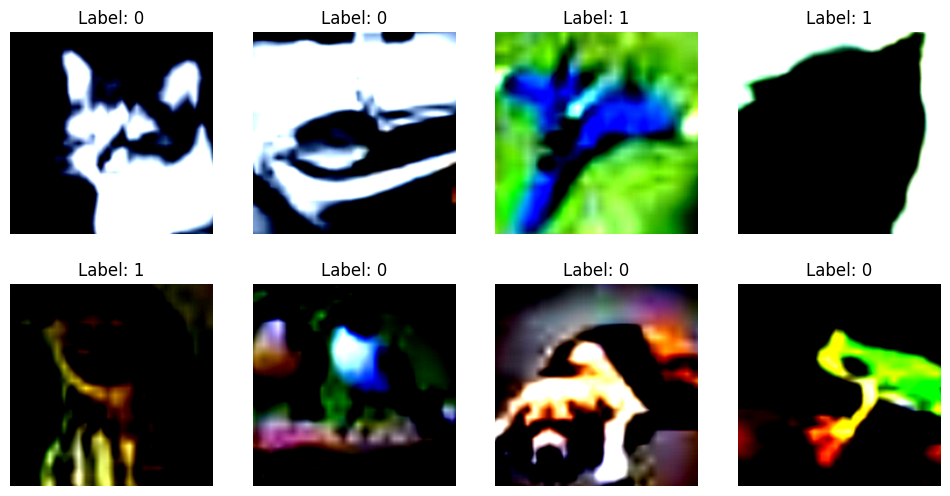

In [ ]:
# get a batch of images and labels from the train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()


#### Validation Data

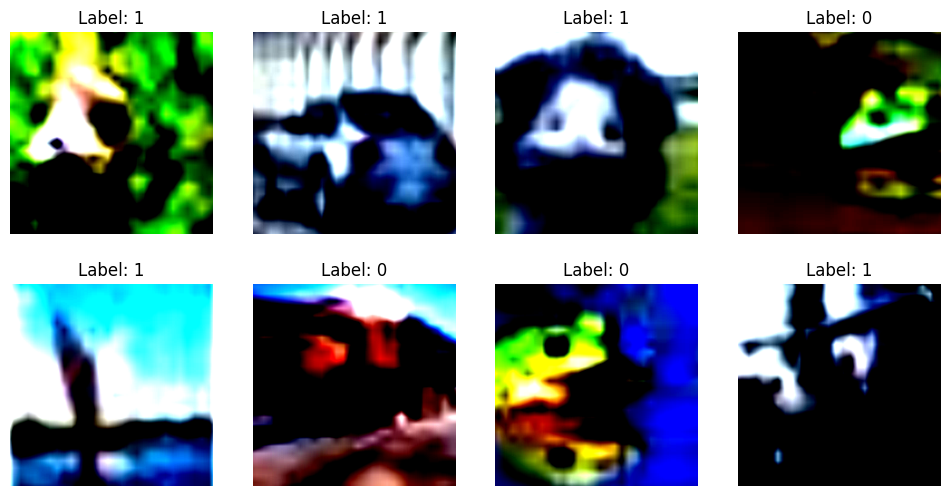

In [ ]:
data_iter = iter(val_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

#### Testing Data

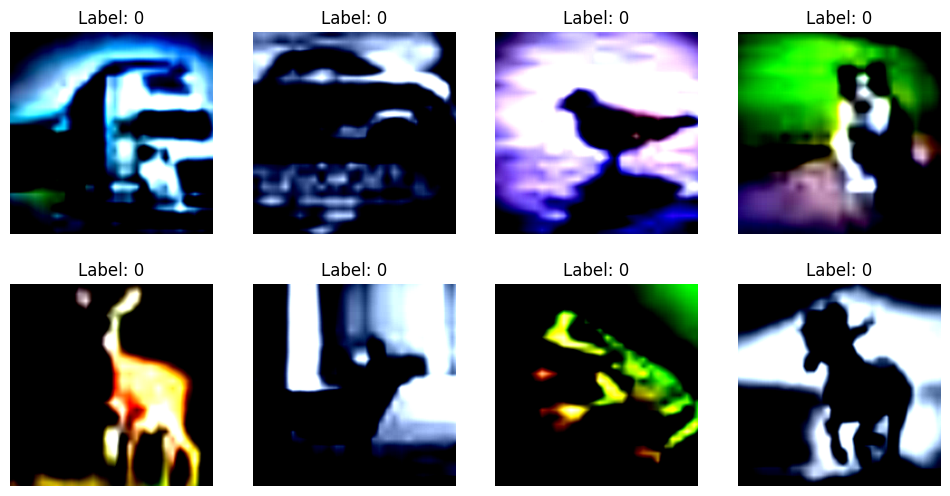

In [ ]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

# get the first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):  # show first 8 images
    ax = axes[i // 4, i % 4]
    img = images[i]  # Get image from batch
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))  # convert tensor to image
    ax.axis('off')  # Hide axis
    ax.set_title(f"Label: {labels[i].item()}")  # show the image lable

plt.show()

In [ ]:
#Loading training and testing data
data_path = "/content/archive/archive"
training_data = datasets.ImageFolder(root=f"{data_path}/train", transform=transform)
testing_data  = datasets.ImageFolder(root=f"{data_path}/test", transform=transform)

In [ ]:
#ResNet fine-tuning setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import random, numpy as np, copy
from torch.backends import cudnn

#Reproducibility
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
cudnn.deterministic = True
cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#Load pretrained ResNet and prepare for fine-tuning
num_classes = len(training_data.classes)
model = models.resnet50(pretrained=True)
for name, param in model.named_parameters():
    if not (name.startswith('layer4') or name.startswith('fc')):
        param.requires_grad = False

#Replace final fully-connected layer
in_feats = model.fc.in_features
model.fc = nn.Linear(in_feats, num_classes)
model = model.to(device)

#Criterion, optimizer, and LR scheduler
criterion = nn.CrossEntropyLoss()   #Loss function defined
#Model optimizer defined
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, momentum=0.9, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)    #Defines learning rate scheduler


In [ ]:
#Manual training/validation split
from torch.utils.data import Subset, DataLoader

trainingSize = 80000
indices = list(range(len(training_data)))
random.shuffle(indices)

train_Indices      = indices[:trainingSize]
validation_Indices = indices[trainingSize:]

newTraining_Data = Subset(training_data, train_Indices)
validation_Data  = Subset(training_data, validation_Indices)

train_loader = DataLoader(newTraining_Data, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(validation_Data,   batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(testing_data,      batch_size=32, shuffle=False, num_workers=4)


In [ ]:
#Training function with optimizer and scheduler
from sklearn.metrics import accuracy_score

#Training function
def train_model_with_metrics(model, train_loader, val_loader,
                             criterion, optimizer, scheduler,
                             device, num_classes,
                             epochs=10, save_path="best_resnet_finetuned.pth"):
    best_model_wts = copy.deepcopy(model.state_dict())    #Stores best weights
    best_val_acc = 0.0
    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_accuracy": []}

    for epoch in range(epochs):
        #Training
        model.train()
        run_loss, preds, labels = 0.0, [], []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            preds.extend(out.argmax(1).cpu().tolist())
            labels.extend(y.cpu().tolist())

        train_loss = run_loss / len(train_loader.dataset)   #Average training loss
        train_acc  = accuracy_score(labels, preds)    #Accuracy on training

        #Validation phase
        model.eval()
        val_loss, v_preds, v_labels = 0.0, [], []
        with torch.no_grad():   #Disables gradient to save on computational cost
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                val_loss += criterion(out, y).item() * x.size(0)
                v_preds.extend(out.argmax(1).cpu().tolist())
                v_labels.extend(y.cpu().tolist())

        val_loss = val_loss / len(val_loader.dataset)   #Average validation loss
        val_acc  = accuracy_score(v_labels, v_preds)    #Accuracy on validation
        scheduler.step()

        history["epoch"].append(epoch+1)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")
        #Saves best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, save_path)
            print("Best model saved.")

    model.load_state_dict(best_model_wts)
    print(f"Training complete. Best Val Acc: {best_val_acc:.4f}")
    return model, history

In [ ]:
#Fine‑tuning the model
model, history = train_model_with_metrics(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    device, num_classes,
    epochs=10, save_path="best_resnet_finetuned.pth"
)

In [ ]:
#Final evaluation on test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Setting model to evalution
model.eval()
with torch.no_grad():
    t_preds, t_labels = [], []    #Stores model predictions
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        t_preds.extend(out.argmax(1).cpu().tolist())
        t_labels.extend(y.cpu().tolist())

print("Test Accuracy :", accuracy_score(t_labels, t_preds))
print("Test Precision:", precision_score(t_labels, t_preds, average='macro'))
print("Test Recall   :", recall_score(t_labels, t_preds, average='macro'))
print("Test F1 Score :", f1_score(t_labels, t_preds, average='macro'))
